In [1]:
!git clone https://github.com/Ronald665/Sensor-Assignment


Cloning into 'Sensor-Assignment'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 1), reused 6 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 828.36 KiB | 6.23 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [ ]:
import os
from google.colab import userdata

# 1. Fetch your secret token securely from Colab
try:
    token = userdata.get('GITHUB_TOKEN')
except Exception:
    print("Please add your 'GITHUB_TOKEN' to the Colab Secrets (Key icon on the left sidebar)!")

# 2. Define your GitHub details
USERNAME = "ibraheem-446"  # Replace with your GitHub username
REPO_NAME = "YSensor_Assignment" # Replace with the repository name
FOLDER_NAME = "YOUR_CLONED_FOLDER"  # Replace with the folder name visible in Colab's sidebar

# 3. Change directory into the project folder
%cd /content/{FOLDER_NAME}

# 4. Configure Git identity
!git config --global user.name "{USERNAME}"
!git config --global user.email "your_email@example.com"

# 5. Stage and commit your changes (including the notebook)
!git add .
!git commit -m "Added my custom Colab notebook to the project"

# 6. Push to YOUR personal GitHub fork
!git push https://{token}@://github.com{USERNAME}/{REPO_NAME}.git main


In [ ]:
import json

# Load the notebook file to inspect its cells
notebook_path = '/content/Sensor-Assignment/Model.ipynb'
with open(notebook_path, 'r', encoding='utf-8') as f:
    nb_data = json.load(f)

# Print a summary of the cells in Model.ipynb
for idx, cell in enumerate(nb_data.get('cells', [])):
    cell_type = cell.get('cell_type', 'unknown')
    source = ''.join(cell.get('source', []))
    print(f"--- Cell {idx} ({cell_type}) ---")
    print(source[:300] + ('...' if len(source) > 300 else ''))
    print()


--- Cell 0 (code) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import...

--- Cell 1 (code) ---
df = pd.read_csv('sensor_readings_24.data', header = None)
df = df.rename(columns={24: 'Target'})
df.head()

--- Cell 2 (code) ---
df.isnull().sum()

--- Cell 3 (code) ---
df['Target'].value_counts(normalize=True).round(2)

--- Cell 4 (code) ---
plt.figure(figsize=(6,3.5))
sns.countplot(x = df['Target'], stat = 'proportion' )
plt.tight_layout()
plt.title('Distribution of Target Features')
plt.show()

--- Cell 5 (code) ---
x = df.drop('Target', axis = 1)
y = df['Target']

--- Cell 6 (code) ---
fig, axes = plt.subplots(nrows = 8, ncols= 3, figsize = (15,20))
axes = axes.flatten()

for i, col in enumerate(x):
    sns.kdeplot(data = df,
          

In [ ]:
# 🚀 Robot Sensor Direction Classifier
# This notebook analyzes multi-channel sensor readings to predict robot movement directions. Below, you will find clean code blocks paired with straightforward descriptions of each machine learning stage.

In [ ]:
# ### 📥 Step 1: Load the Dataset
# We load the raw 24-channel sensor data and assign a proper name ('Target') to our label column.
import pandas as pd

df = pd.read_csv('/content/Sensor-Assignment/sensor_readings_24.data', header = None)
df = df.rename(columns={24: 'Target'})
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,Target
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


In [ ]:
# ### 🔍 Step 2: Quality Check
# We verify that our dataset does not contain any missing or null values.
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
# ### 📊 Step 3: Check Class Distribution
# We measure the proportion of each robot action (target label) to understand the class balance.
df['Target'].value_counts(normalize=True).round(2)

,proportion
Target,
Move-Forward,0.40
Sharp-Right-Turn,0.38
Slight-Right-Turn,0.15
Slight-Left-Turn,0.06


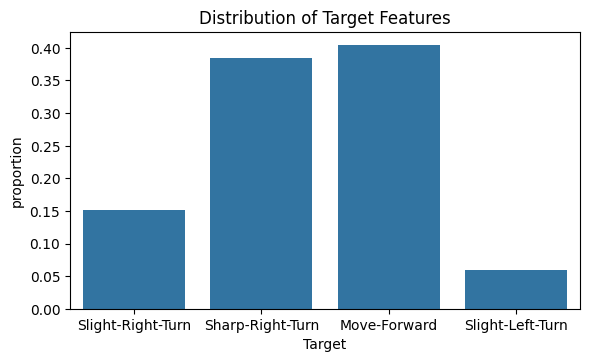

In [ ]:
# ### 📊 Step 4: Class Distribution Plot
# Visualizing target distributions to inspect class proportions clearly.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,3.5))
sns.countplot(x = df['Target'], stat = 'proportion' )
plt.tight_layout()
plt.title('Distribution of Target Features')
plt.show()

In [ ]:
# ### ✂️ Step 5: Separate Features & Targets
# Isolating the independent variables (sensor features) from the dependent target label.
x = df.drop('Target', axis = 1)
y = df['Target']

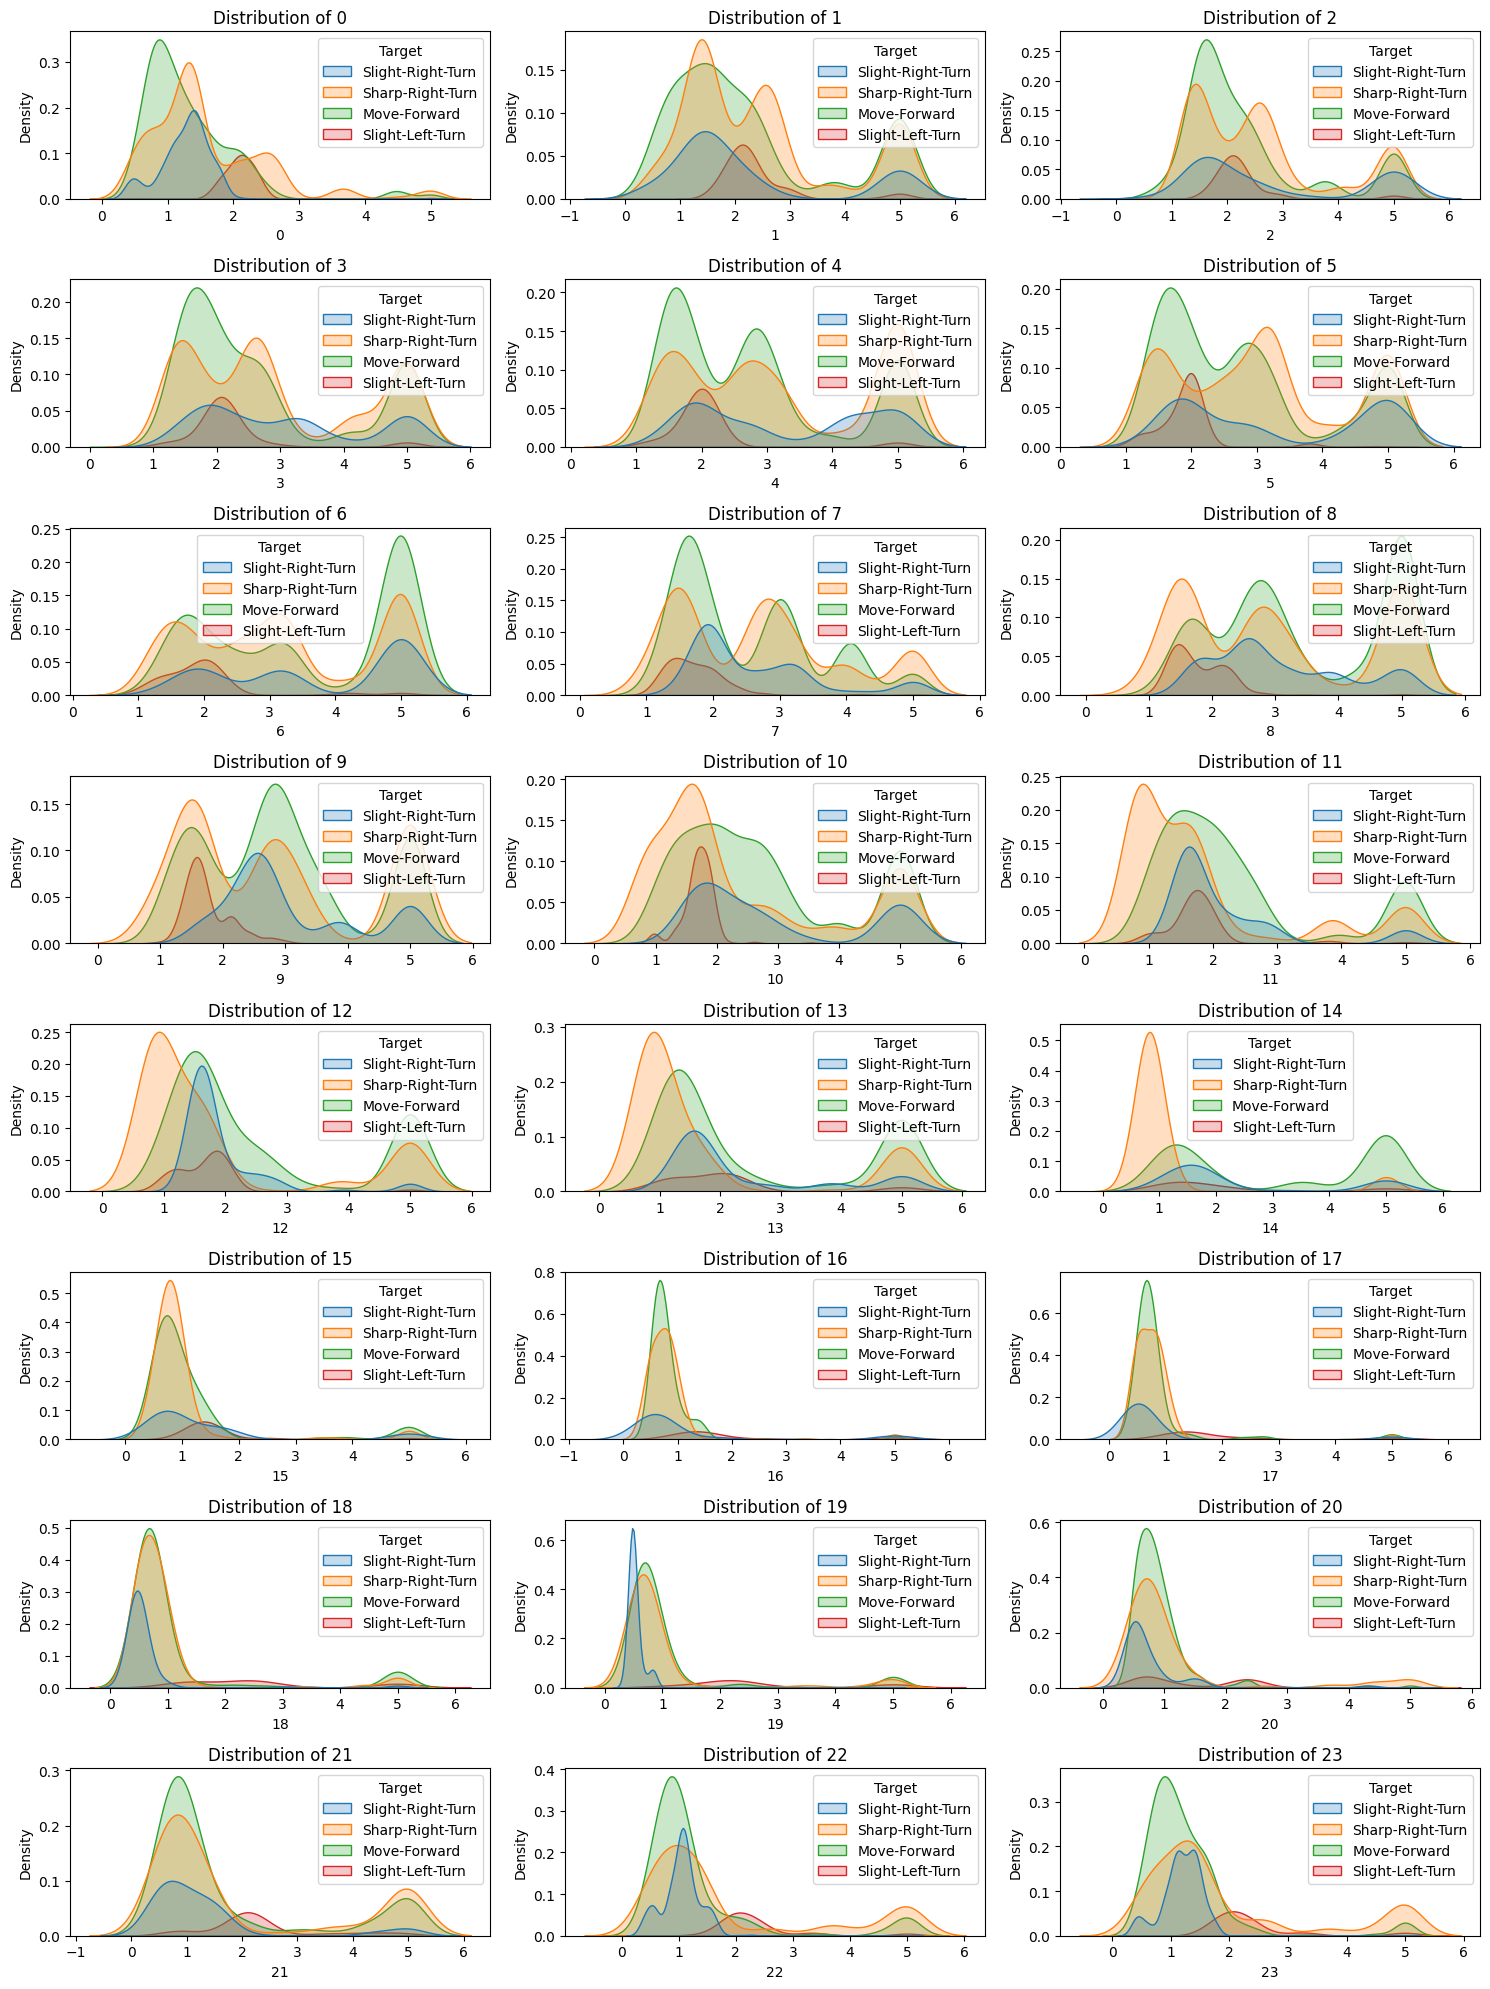

In [ ]:
# ### 📈 Step 6: Feature Distributions
# Estimating density distributions for all 24 sensors to spot unique class profiles.
fig, axes = plt.subplots(nrows = 8, ncols= 3, figsize = (15,20))
axes = axes.flatten()

for i, col in enumerate(x):
    sns.kdeplot(data = df,
               x = df[col],
               hue = y,
               ax = axes[i],
               fill = True)
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
# ### 📏 Step 7: Inspect Data Shape
# Print the total number of records and features present.
df.shape

(5456, 25)

In [ ]:
# ### 🚪 Step 8: Train-Test Split
# Hold out 30% of our dataset for a clean, final unbiased evaluation of our model.
from sklearn.model_selection import train_test_split

x_model, x_test, y_model, y_test = train_test_split(x, y ,
                                                    test_size = 0.3,
                                                    random_state = 42,
                                                    shuffle = True,
                                                    stratify = y)

## Model Building

Since features are majorly not normally distributed ill use Mim max scaler

In [ ]:
# ### ⚖️ Step 9: Scaling & Label Encoding
# Standardizing feature ranges to [0, 1] using MinMaxScaler and mapping actions to integers.
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

x_model_sel = x.copy()
y_model_sel = y.copy()

scaler_model_sel = MinMaxScaler()
encoder_y_model_sel = LabelEncoder()

x_model_sel = scaler_model_sel.fit_transform(x_model_sel)
y_model_sel = encoder_y_model_sel.fit_transform(y_model_sel)

In [ ]:
# ### 🔄 Step 10: Setting Up Stratified K-Fold
# Preparing split definitions to run stable cross-validation evaluations.
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state=42)

In [ ]:
# ### 🧠 Baseline 1: Logistic Regression CV Score
np.mean(cross_val_score(LogisticRegression(),
                        x_model_sel,
                        y_model_sel,
                        scoring = 'accuracy',
                        n_jobs = -1,
                        verbose = 0,
                        cv = cv))

np.float64(0.686586053726292)

In [ ]:
# ### 🧠 Baseline 2: Decision Tree CV Score
np.mean(cross_val_score(DecisionTreeClassifier(),
                x_model_sel,
                y_model_sel,
                n_jobs = -1,
               verbose = 0,
                cv = cv))

np.float64(0.9941348294235552)

In [ ]:
# ### 🧠 Baseline 3: XGBoost CV Score
np.mean(cross_val_score(XGBClassifier(),
                x_model_sel,
                y_model_sel,
                n_jobs = -1,
               verbose = 0,
                cv = cv))

np.float64(0.9974338829517564)

In [ ]:
# ### 🧠 Baseline 4: LightGBM CV Score (Champion)
np.mean(cross_val_score(LGBMClassifier(),
                x_model_sel,
                y_model_sel,
                n_jobs = -1,
               verbose = 0,
                cv = cv))

np.float64(0.9972505648949278)

## Model building

In [ ]:
# ### 🏷️ Step 11: Label Encoding the Train-Test Sets
# Creating consistent classes for our split model and test datasets.
encoder = LabelEncoder()
y_model = encoder.fit_transform(y_model)
y_test = encoder.transform(y_test)

In [ ]:
oof_pred = np.zeros(len(x_model))
test_pred = np.zeros((len(x_test), 4))
fold_pred = []

fold_cv = StratifiedKFold(random_state=42, n_splits = 5, shuffle = True)

for fold, (train_idx, val_idx) in enumerate(fold_cv.split(x_model, y_model)):
    x_train, x_val = x_model.iloc[train_idx].copy(), x_model.iloc[val_idx].copy()
    y_train, y_val = y_model[train_idx], y_model[val_idx]

    scaler = MinMaxScaler()
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)

    # verbose=-1 silences the "No further splits" info/warning logs
    model = LGBMClassifier(verbose=-1)
    model.fit(x_train, y_train)

    oof_pred[val_idx] = model.predict(x_val)
    x_test_scaled = scaler.transform(x_test)
    test_pred += model.predict_proba(x_test_scaled) / 5

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

In [ ]:
# ### 🏋️ Step 12: Pipeline Training (MinMaxScaler + LGBM Classifier)
# Wrapping preprocessing and training into a leakage-safe Pipeline within Stratified K-Fold CV.
from sklearn.pipeline import Pipeline

oof_pred = np.zeros(len(x_model))
test_pred = np.zeros((len(x_test), len(encoder.classes_)))

fold_cv = StratifiedKFold(random_state=42, n_splits=5, shuffle=True)

X_model_arr = x_model.values
X_test_arr = x_test.values

for fold, (train_idx, val_idx) in enumerate(fold_cv.split(X_model_arr, y_model)):
    X_train, X_val = X_model_arr[train_idx], X_model_arr[val_idx]
    y_train, y_val = y_model[train_idx], y_model[val_idx]

    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('classifier', LGBMClassifier(verbose=-1))
    ])

    pipeline.fit(X_train, y_train)
    oof_pred[val_idx] = pipeline.predict(X_val)
    test_pred += pipeline.predict_proba(X_test_arr) / 5

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ut

In [ ]:
# ### 🔢 Step 13: Decode Predictions
# Mapping numerical predictions back to categorical action names.
test_pred = np.argmax(test_pred, axis = 1)
test_pred_label = encoder.inverse_transform(test_pred)
y_test_label = encoder.inverse_transform(y_test)

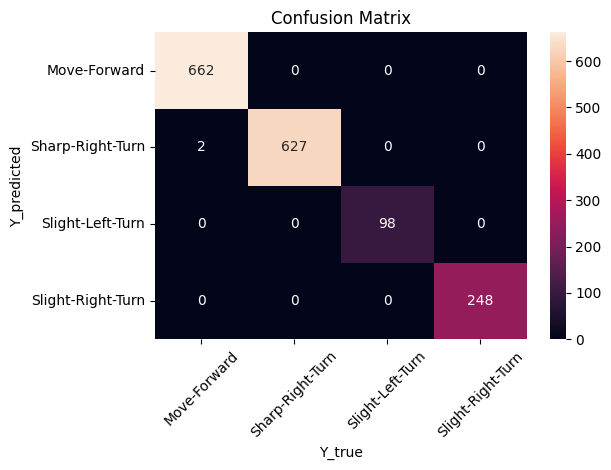

In [ ]:
# ### 🎯 Step 14: Confusion Matrix Plot
# Evaluating confusion distributions visually across target labels.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_label, test_pred_label)
sns.heatmap(cm, annot = True,
            fmt='.0f',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Y_true')
plt.ylabel('Y_predicted')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [ ]:
# ### 🎯 Step 15: Print Classification Metrics
# Output the final precision, recall, and overall F1-score evaluation metrics.
from sklearn.metrics import classification_report

print(classification_report(y_test_label, test_pred_label))

                   precision    recall  f1-score   support

     Move-Forward       1.00      1.00      1.00       662
 Sharp-Right-Turn       1.00      1.00      1.00       629
 Slight-Left-Turn       1.00      1.00      1.00        98
Slight-Right-Turn       1.00      1.00      1.00       248

         accuracy                           1.00      1637
        macro avg       1.00      1.00      1.00      1637
     weighted avg       1.00      1.00      1.00      1637

